In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.algorithms import VQC
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
# Function to Build the Quantum Circuit

# -----------------------
# Feature Map without entanglement to provide a classical map into a quantum circuit
# -----------------------
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# -----------------------
# Feature Map
# -----------------------
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N-1):
        qc.cx(i, i+1)
        qc.rz(x[i] * x[i+1], i+1)
        qc.cx(i, i+1)
    qc.barrier()
    return qc

# -----------------------
# Variational Model
# -----------------------
def Ansatz(N):
    theta = ParameterVector('theta', 2*N)
    qc = QuantumCircuit(N)
    for i in range(N):
        qc.ry(theta[i], i)
    qc.barrier()
    for i in range(N-1):
        for j in range(i+1,N):
            qc.cx(i, j)
    qc.barrier()
    for i in range(N):
        qc.ry(theta[i+N], i)
    return qc


In [4]:
# Read and scale data from Iris Dataset
df=pd.read_csv("Iris/iris.data",header=None, 
               names = ["S-length", "S-width", "P-length","P-width","label"])


# Filter for binary classification
df = df[df["label"].isin(["Iris-setosa", "Iris-versicolor"])]

feature_col = ["S-length", "S-width", "P-length","P-width"]
label_col   = "label"

x = df[feature_col].values
y = LabelEncoder().fit_transform(df["label"].values)

# Conversion features in [-1,1]
scaler   = MinMaxScaler(feature_range=(-1, 1))        
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42, stratify=y
)

N = len(feature_col)
# Creating the Circuits' parts
easy_feature_map = EasyFeatureMap(N)
feature_map = FeatureMap(N)
ansatz      = Ansatz(N)

## QNN

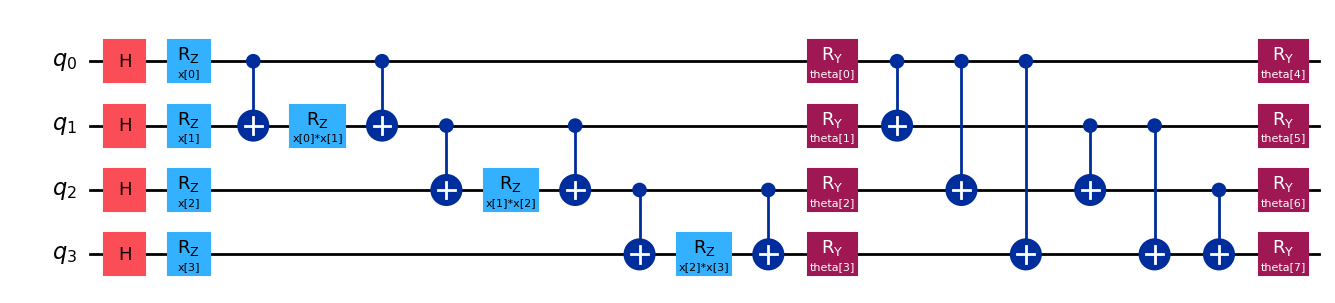

In [5]:
qc = feature_map.copy().compose(ansatz.copy())
qc.draw("mpl", style="iqp", plot_barriers=False)

## easy Quantum Model

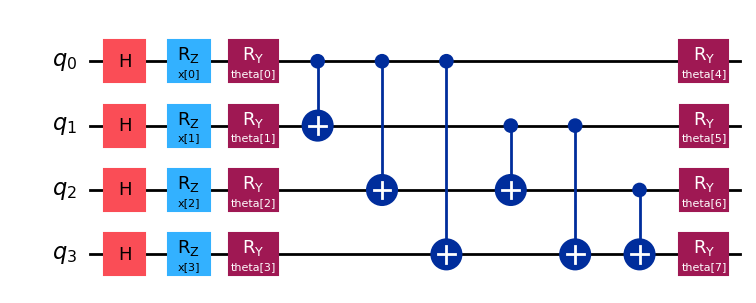

In [6]:
easy_qc = easy_feature_map.copy().compose(ansatz.copy())
easy_qc.draw("mpl", style="iqp", plot_barriers=False)

## Evaluating Loss for QNNs

In [6]:
# Function to get the loss value
def make_adam_tracker(loss_list, maxiter=100,N=4):
    log_n = np.log2(N)
    def adam_with_tracking(fun, x0, jac=None, **kwargs):
        optimizer = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(weights):
            loss = fun(weights)
            loss_norm = float(loss) / log_n
            loss_list.append(float(loss_norm))
            #pct = len(loss_list)/maxiter * 100
            #bar = "#"*int( pct//5 ) + "."*( 20 - int(pct//5) )  
            #print(f"\r[{bar}] iter {len(loss_list):>3d} | loss: {loss:.4f}",flush=True)
            return jac(weights)
        return optimizer.minimize(fun=fun, x0=x0, jac=tracked_jac)
    return adam_with_tracking

# ── Optimizing the circuits ───────────────────────────────────────────────────────
qc_loss      = []
qc_easy_loss = []

vqc = VQC(
    sampler=StatevectorSampler(),
    feature_map=FeatureMap(N),
    ansatz=Ansatz(N),
    optimizer=make_adam_tracker(qc_loss),       
)
vqc.fit(x_train, y_train)

vqc_easy = VQC(
    sampler=StatevectorSampler(),
    feature_map=EasyFeatureMap(N),
    ansatz=Ansatz(N),
    optimizer=make_adam_tracker(qc_easy_loss),
)
vqc_easy.fit(x_train, y_train)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


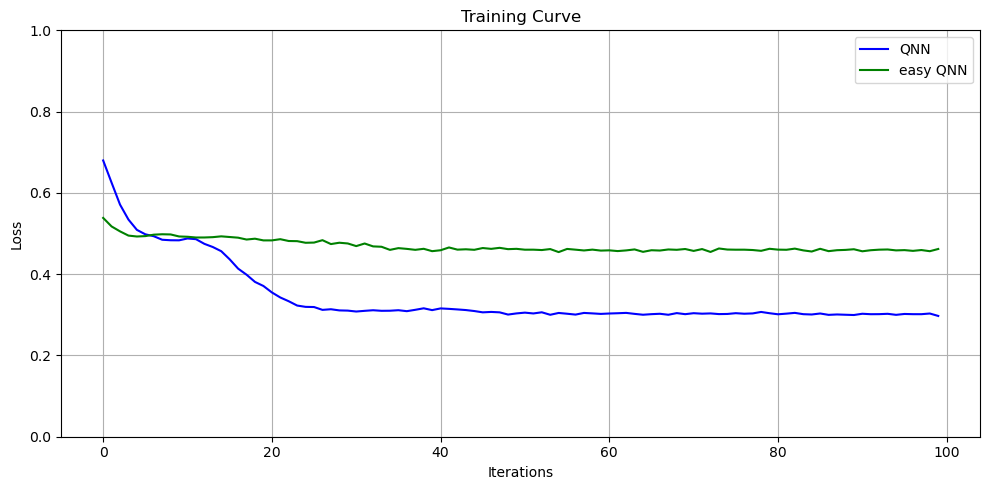

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(qc_loss, label = "QNN", color = 'blue')
plt.plot(qc_easy_loss, label = "easy QNN", color = 'green')
plt.ylim([0,1])
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

## 100 Trial Experiment

In [ ]:
from qiskit.primitives import StatevectorSampler

N_TRIALS = 2
MAX_ITER = 100

# Storico per entrambi i modelli
all_losses_qc      = []   # (N_TRIALS, n_iter)
all_losses_easy    = []   # (N_TRIALS, n_iter)
all_weights_qc     = []   # (N_TRIALS, n_iter, n_weights)
all_weights_easy   = []   # (N_TRIALS, n_iter, n_weights)
all_train_acc_qc   = []
all_test_acc_qc    = []
all_train_acc_easy = []
all_test_acc_easy  = []

def make_adam_tracker_with_weights(loss_list, weights_list, maxiter=MAX_ITER, N=4):
    log_n = np.log2(N)
    def adam_with_tracking(fun, x0, jac=None, **kwargs):
        optimizer = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(weights):
            loss = fun(weights)
            loss_norm = float(loss) / log_n
            loss_list.append(loss_norm)
            weights_list.append(weights.copy())
            #pct = len(loss_list) / maxiter * 100
            #bar = '#' * int(pct // 5) + '.' * (20 - int(pct // 5))
            #print(f'\r[{bar}] iter {len(loss_list):>3d} | loss: {loss:.4f}', flush=True)
            return jac(weights)
        return optimizer.minimize(fun=fun, x0=x0, jac=tracked_jac)
    return adam_with_tracking

for trial in range(N_TRIALS):
    print(f'\n── Trial {trial+1:>3d}/{N_TRIALS} ──')

    trial_loss_qc    = []
    trial_loss_easy  = []
    trial_weights_qc   = []
    trial_weights_easy = []

    # ── QNN (FeatureMap with entanglement) ──
    trial_vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=FeatureMap(N),
        ansatz=Ansatz(N),
        optimizer=make_adam_tracker_with_weights(trial_loss_qc, trial_weights_qc, MAX_ITER, N),
    )
    trial_vqc.fit(x_train, y_train)
    all_losses_qc.append(trial_loss_qc)
    all_weights_qc.append(trial_weights_qc)
    all_train_acc_qc.append(trial_vqc.score(x_train, y_train))
    all_test_acc_qc.append(trial_vqc.score(x_test, y_test))
    print(f'  QNN   -> train: {all_train_acc_qc[-1]:.2%} | test: {all_test_acc_qc[-1]:.2%}')

    # ── easy QNN (EasyFeatureMap without entanglement) ──
    trial_vqc_easy = VQC(
        sampler=StatevectorSampler(),
        feature_map=EasyFeatureMap(N),
        ansatz=Ansatz(N),
        optimizer=make_adam_tracker_with_weights(trial_loss_easy, trial_weights_easy, MAX_ITER, N),
    )
    trial_vqc_easy.fit(x_train, y_train)
    all_losses_easy.append(trial_loss_easy)
    all_weights_easy.append(trial_weights_easy)
    all_train_acc_easy.append(trial_vqc_easy.score(x_train, y_train))
    all_test_acc_easy.append(trial_vqc_easy.score(x_test, y_test))
    print(f'  easy  -> train: {all_train_acc_easy[-1]:.2%} | test: {all_test_acc_easy[-1]:.2%}')

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



── Trial   1/2 ──


In [ ]:
# Tronca al minimo numero di iterazioni tra tutti i trial
min_iter_qc   = min(len(l) for l in all_losses_qc)
min_iter_easy = min(len(l) for l in all_losses_easy)
min_iter      = min(min_iter_qc, min_iter_easy)

loss_arr_qc   = np.array([l[:min_iter] for l in all_losses_qc])   # (N_TRIALS, min_iter)
loss_arr_easy = np.array([l[:min_iter] for l in all_losses_easy])  # (N_TRIALS, min_iter)
iters         = np.arange(1, min_iter + 1)

loss_mean_qc   = loss_arr_qc.mean(axis=0)
loss_std_qc    = loss_arr_qc.std(axis=0)
loss_mean_easy = loss_arr_easy.mean(axis=0)
loss_std_easy  = loss_arr_easy.std(axis=0)

print(f'QNN   - test acc media:  {np.mean(all_test_acc_qc):.2%} ± {np.std(all_test_acc_qc):.2%}')
print(f'easy  - test acc media:  {np.mean(all_test_acc_easy):.2%} ± {np.std(all_test_acc_easy):.2%}')

In [ ]:
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN, EffectiveDimension

estimator  = StatevectorEstimator()
observable = SparsePauliOp('Z' + 'I' * (N - 1))

def make_estimator_qnn(feature_map_fn, ansatz_fn, N):
    fm   = feature_map_fn(N)
    ans  = ansatz_fn(N)
    circ = fm.compose(ans)
    x_p     = [p for p in circ.parameters if p.name.startswith('x')]
    theta_p = [p for p in circ.parameters if p.name.startswith('theta')]
    return EstimatorQNN(
        circuit=circ,
        observables=observable,
        input_params=x_p,
        weight_params=theta_p,
        estimator=estimator,
    )

qnn_ed      = make_estimator_qnn(FeatureMap,     Ansatz, N)
qnn_ed_easy = make_estimator_qnn(EasyFeatureMap, Ansatz, N)

# Tronca al minimo numero di iterazioni tra tutti i trial
min_iter_qc   = min(len(l) for l in all_losses_qc)
min_iter_easy = min(len(l) for l in all_losses_easy)
min_iter      = min(min_iter_qc, min_iter_easy)

loss_arr_qc   = np.array([l[:min_iter] for l in all_losses_qc])
loss_arr_easy = np.array([l[:min_iter] for l in all_losses_easy])
iters         = np.arange(1, min_iter + 1)

loss_mean_qc   = loss_arr_qc.mean(axis=0)
loss_std_qc    = loss_arr_qc.std(axis=0)
loss_mean_easy = loss_arr_easy.mean(axis=0)
loss_std_easy  = loss_arr_easy.std(axis=0)

ed_step  = 10
ed_iters = list(range(0, min_iter, ed_step))

print(f'QNN   - test acc media: {np.mean(all_test_acc_qc):.2%} ± {np.std(all_test_acc_qc):.2%}')
print(f'easy  - test acc media: {np.mean(all_test_acc_easy):.2%} ± {np.std(all_test_acc_easy):.2%}')
print(f'Iterazioni salvate: {min_iter} | Checkpoint ED: {ed_iters}')

In [ ]:
# Calcola ED e FIM in un unico loop: run_monte_carlo() chiamato UNA sola volta per iterazione
ed_values_qc    = []
ed_values_easy  = []
fim_values_qc   = []
fim_values_easy = []

print('Calcolo ED + FIM (loop unificato)...')
for it in ed_iters:
    w_qc   = np.array([all_weights_qc[t][it]   for t in range(N_TRIALS)])
    w_easy = np.array([all_weights_easy[t][it]  for t in range(N_TRIALS)])

    # ── QNN: un solo run_monte_carlo() → ED + FIM ──
    ed_qc  = EffectiveDimension(qnn=qnn_ed,      weight_samples=w_qc,   input_samples=x_train)
    grads_qc,   outputs_qc   = ed_qc.run_monte_carlo()
    fim_qc                   = ed_qc.get_fisher_information(grads_qc, outputs_qc)
    norm_fim_qc, _           = ed_qc.get_normalized_fisher(fim_qc)
    try:
        val_qc = ed_qc._get_effective_dimension(norm_fim_qc, dataset_size=len(x_train))
        val_qc = float(val_qc) if not np.isnan(val_qc) else np.nan
    except Exception:
        val_qc = np.nan
    # Riduce (N_TRIALS * n_input_samples, n_w, n_w) → (N_TRIALS, n_w, n_w) mediando sugli input
    n_input = len(x_train)
    fim_qc_trial = fim_qc.reshape(N_TRIALS, n_input, fim_qc.shape[-2], fim_qc.shape[-1]).mean(axis=1)

    # ── easy QNN: un solo run_monte_carlo() → ED + FIM ──
    ed_easy = EffectiveDimension(qnn=qnn_ed_easy, weight_samples=w_easy, input_samples=x_train)
    grads_easy, outputs_easy = ed_easy.run_monte_carlo()
    fim_easy                 = ed_easy.get_fisher_information(grads_easy, outputs_easy)
    norm_fim_easy, _         = ed_easy.get_normalized_fisher(fim_easy)
    try:
        val_easy = ed_easy._get_effective_dimension(norm_fim_easy, dataset_size=len(x_train))
        val_easy = float(val_easy) if not np.isnan(val_easy) else np.nan
    except Exception:
        val_easy = np.nan
    fim_easy_trial = fim_easy.reshape(N_TRIALS, n_input, fim_easy.shape[-2], fim_easy.shape[-1]).mean(axis=1)

    ed_values_qc.append(val_qc)
    ed_values_easy.append(val_easy)
    fim_values_qc.append(fim_qc_trial)    # shape: (N_TRIALS, n_weights, n_weights)
    fim_values_easy.append(fim_easy_trial)

    print(f'  iter {it:>3d} | ED QNN: {val_qc} | ED easy: {val_easy} | FIM/trial shape: {fim_qc_trial.shape}')

fim_arr_qc   = np.array(fim_values_qc)    # (n_ed_iters, N_TRIALS, n_weights, n_weights)
fim_arr_easy = np.array(fim_values_easy)


In [ ]:
# Stampa metriche FIM al checkpoint iniziale
fim_trace_qc   = fim_arr_qc.trace(axis1=-2, axis2=-1)    # (n_ed_iters, N_TRIALS)
fim_trace_easy = fim_arr_easy.trace(axis1=-2, axis2=-1)
eigvals_qc     = np.linalg.eigvalsh(fim_arr_qc)
eigvals_easy   = np.linalg.eigvalsh(fim_arr_easy)
threshold      = 1e-6
rank_qc        = (eigvals_qc   > threshold).sum(axis=-1)
rank_easy      = (eigvals_easy > threshold).sum(axis=-1)

print(f'FIM trace media QNN  (iter 0): {fim_trace_qc[0].mean():.4f} ± {fim_trace_qc[0].std():.4f}')
print(f'FIM trace media easy (iter 0): {fim_trace_easy[0].mean():.4f} ± {fim_trace_easy[0].std():.4f}')
print(f'Rango effettivo QNN  (iter 0): {rank_qc[0].mean():.1f} / {2*N}')
print(f'Rango effettivo easy (iter 0): {rank_easy[0].mean():.1f} / {2*N}')


In [ ]:
d = 2 * N  # numero di parametri allenabili

ed_arr_qc   = np.array(ed_values_qc,   dtype=float) / d
ed_arr_easy = np.array(ed_values_easy, dtype=float) / d
mask_qc   = ~np.isnan(ed_arr_qc)
mask_easy = ~np.isnan(ed_arr_easy)

fig, axes = plt.subplots(5, 1, figsize=(10, 22))

# ── 1. Loss media ± std ───────────────────────────────────────
axes[0].plot(iters, loss_mean_qc,   label='QNN',      color='blue')
axes[0].fill_between(iters, loss_mean_qc - loss_std_qc, loss_mean_qc + loss_std_qc,
                     alpha=0.2, color='blue')
axes[0].plot(iters, loss_mean_easy, label='easy QNN', color='forestgreen')
axes[0].fill_between(iters, loss_mean_easy - loss_std_easy, loss_mean_easy + loss_std_easy,
                     alpha=0.2, color='forestgreen')
axes[0].set_ylim([0, 1])
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title(f'Loss (mean ± std over {N_TRIALS} trials)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# ── 2. Effective Dimension / d ────────────────────────────────
axes[1].plot(np.array(ed_iters)[mask_qc],   ed_arr_qc[mask_qc],
             marker='o', color='blue',        label='QNN')
axes[1].plot(np.array(ed_iters)[mask_easy], ed_arr_easy[mask_easy],
             marker='s', color='forestgreen', label='easy QNN')
axes[1].set_ylim([0, 1])
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Effective Dimension / d')
axes[1].set_title(f'Normalised Effective Dimension during training (d={d})')
axes[1].legend()
axes[1].grid(True)

# ── 3. FIM Trace ± std ───────────────────────────────────────
fim_trace_qc   = fim_arr_qc.trace(axis1=-2, axis2=-1)    # (n_ed_iters, N_TRIALS)
fim_trace_easy = fim_arr_easy.trace(axis1=-2, axis2=-1)
axes[2].plot(ed_iters, fim_trace_qc.mean(axis=1),   color='blue',        label='QNN')
axes[2].fill_between(ed_iters,
    fim_trace_qc.mean(axis=1) - fim_trace_qc.std(axis=1),
    fim_trace_qc.mean(axis=1) + fim_trace_qc.std(axis=1),
    alpha=0.2, color='blue')
axes[2].plot(ed_iters, fim_trace_easy.mean(axis=1), color='forestgreen', label='easy QNN')
axes[2].fill_between(ed_iters,
    fim_trace_easy.mean(axis=1) - fim_trace_easy.std(axis=1),
    fim_trace_easy.mean(axis=1) + fim_trace_easy.std(axis=1),
    alpha=0.2, color='forestgreen')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('FIM Trace')
axes[2].set_title('Fisher Information Matrix (trace) during training')
axes[2].legend()
axes[2].grid(True)

# ── 4. Autovalori FIM all'ultima iterazione ───────────────────
eigvals_qc   = np.linalg.eigvalsh(fim_arr_qc)    # (n_ed_iters, N_TRIALS, n_weights)
eigvals_easy = np.linalg.eigvalsh(fim_arr_easy)
axes[3].boxplot(
    [eigvals_qc[-1].flatten(), eigvals_easy[-1].flatten()],
    labels=['QNN', 'easy QNN'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
axes[3].set_yscale('log')
axes[3].set_ylabel('FIM Eigenvalues (log scale)')
axes[3].set_title(f'FIM Eigenvalue distribution — iteration {ed_iters[-1]}')
axes[3].grid(True)

# ── 5. Rango effettivo FIM ────────────────────────────────────
threshold = 1e-6
rank_qc   = (eigvals_qc   > threshold).sum(axis=-1)   # (n_ed_iters, N_TRIALS)
rank_easy = (eigvals_easy > threshold).sum(axis=-1)
axes[4].plot(ed_iters, rank_qc.mean(axis=1),   color='blue',        label='QNN')
axes[4].plot(ed_iters, rank_easy.mean(axis=1), color='forestgreen', label='easy QNN')
axes[4].set_xlabel('Iteration')
axes[4].set_ylabel('Effective Rank')
axes[4].set_title(f'FIM Effective Rank (threshold={threshold})')
axes[4].set_ylim([0, 2*N + 1])
axes[4].legend()
axes[4].grid(True)

plt.tight_layout()
plt.show()
